In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import griddata
import os
import glob
import re

In [49]:
saveFigures=True
saveAllFigures = False # include 2d plots
saveEvery = 10 # save every nth figure to avoid saving too many
showFigures = False

In [ ]:
results_dir = 'Results'
face_filename = 'faceNodesRightCPSFullCycleNoPower.csv'#'faceNodesRightCPSNoMacor.csv' # "faceNodesRightCPSMacor.csv"
face_nodes_file = os.path.join(results_dir, face_filename)
name_tag = 'fullShotNewMesh5sSteady'#"fullShot1sSteadyNoPower"#"RampEvapHeaterMacor60s"

# Load face nodes 
face_nodes_df = pd.read_csv(face_nodes_file, encoding="utf-8-sig")
target_node_ids = set(face_nodes_df['Node Number'])\

# Load temperature data
file_pattern = os.path.join(results_dir, f"{name_tag}_*s.csv")
data_files = glob.glob(file_pattern) 

In [51]:
# from M. Parsons vapor_pressure.py

def P_vapor(T):
    # T [K]
    # P [Pa]
    return 10**(12.4037 - 8283.1/T - 0.7081*np.log10(T))


def G_max(T):
    # T [K]
    # G [uc]
    
    R = 8.3145 # [J/mol-K]
    g = 10 # [m/s^2]
    pi = 3.141593
    M = 6.941 # [g/mol] 
    
    #uc = 1 # [kg/m^2/s]
    #uc = 360 # [g/cm^2/hour]
    #uc = 0.1 # convert to [g/cm^2/s]
    uc = 0.1 * (6.022e23 / 6.941) # [1/cm^2/s]
    
    return P_vapor(T) / (g * np.sqrt(2*pi*R*T/M)) * uc

In [52]:

# Define the interpolation grid
x_min, x_max = 0.01, 0.06
y_min, y_max = -0.05, 0.05
num_points = 1000
grid_x, grid_y = np.mgrid[x_min:x_max:num_points*1j, y_min:y_max:num_points*1j]
# Calculate the area of a single grid cell in cm^2
dx_m = (x_max - x_min) / (num_points - 1)
dy_m = (y_max - y_min) / (num_points - 1)
dx_cm = dx_m * 100
dy_cm = dy_m * 100
dA_cm2 = dx_cm * dy_cm

In [53]:
summary_temps = []
times = []
summary_evap_rates = []
counter = 0
file_counter = 0
for file_path in data_files: 
    print(file_counter, "/", len(data_files))
    file_counter += 1
    time_match = re.search(rf"{name_tag}_(\d+\.?\d*)s", file_path)
    time_str = time_match.group(1) if time_match else "Unknown"
    
    print(f"Processing results for t = {time_str}s...")

    # Load data
    df = pd.read_csv(file_path, encoding="latin1", sep='\t')
    # Filter for face nodes
    nodes_subset = df[df['Node Number'].isin(target_node_ids)].copy()
    
    if nodes_subset.empty:
        print(f"Warning: No face nodes found in {file_path}")
        continue
    points = nodes_subset[['X Location (m)', 'Y Location (m)']].values
    values = nodes_subset.iloc[:, 4].values
    
    #interpolate temperature data 
    grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

    #convert temperature to evaporation rate
    evaporation_rate = G_max(grid_z + 273.15)*6.94/6.022e23 # Convert to g/cm^2/s

    total_evaporation_rate = np.nansum(evaporation_rate) * dA_cm2

    avg_temp = np.nanmean(grid_z)
    summary_temps.append(avg_temp)
    summary_evap_rates.append(total_evaporation_rate)
    times.append(float(time_str))
    print(f"Total Evaporation Rate: {total_evaporation_rate:.4e} g/s | Average Surface Temp: {avg_temp:.2f} °C")

    plt.figure(figsize=(9, 7))
    
    im = plt.imshow(grid_z.T, 
                    extent=(x_min, x_max, y_min, y_max), 
                    origin='lower', 
                    cmap='coolwarm', 
                    aspect='equal',
                    vmin=200, vmax=800)
    
    plt.colorbar(im, label='Temperature (°C)')
    plt.title(f"Surface Temp: {name_tag} | Time: {time_str}s")
    plt.xlabel("X Location (m)")
    plt.ylabel("Y Location (m)")
    if saveFigures and saveAllFigures and counter == 0:
        save_name = f'temp_{time_str}s_{name_tag}.png'
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
    if showFigures:
        plt.show()
    plt.close()

    plt.figure(figsize=(9, 7))
    
    im = plt.imshow(evaporation_rate.T, 
                    extent=(x_min, x_max, y_min, y_max), 
                    origin='lower', 
                    cmap='viridis', 
                    norm=colors.LogNorm(vmin=1e-8, vmax=3e-2),
                    aspect='equal'
                    )
    
    plt.colorbar(im, label='Evaporation Rate (g/s/cm²)')
    plt.title(f"Evaporation Rate: {name_tag} | Time: {time_str}s")
    plt.xlabel("X Location (m)")
    plt.ylabel("Y Location (m)")
    if saveFigures and saveAllFigures and counter == 0:
        save_name = f'evapRate_{time_str}s_{name_tag}.png'
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
    if showFigures:
        plt.show()
    plt.close()
    
    counter += 1
    if counter == saveEvery:
        counter = 0
    


print("--- All files processed successfully ---")

0 / 369
Processing results for t = 131s...
Total Evaporation Rate: 1.5248e-02 g/s | Average Surface Temp: 545.46 °C
1 / 369
Processing results for t = 1296s...
Total Evaporation Rate: 8.4108e-05 g/s | Average Surface Temp: 412.83 °C
2 / 369
Processing results for t = 150.5s...
Total Evaporation Rate: 5.0465e-02 g/s | Average Surface Temp: 601.00 °C
3 / 369
Processing results for t = 218s...
Total Evaporation Rate: 3.3325e-03 g/s | Average Surface Temp: 519.81 °C
4 / 369
Processing results for t = 536s...
Total Evaporation Rate: 8.7786e-04 g/s | Average Surface Temp: 479.33 °C
5 / 369
Processing results for t = 166s...
Total Evaporation Rate: 1.1216e-02 g/s | Average Surface Temp: 550.42 °C
6 / 369
Processing results for t = 189s...
Total Evaporation Rate: 5.0619e-03 g/s | Average Surface Temp: 529.25 °C
7 / 369
Processing results for t = 170s...
Total Evaporation Rate: 9.1516e-03 g/s | Average Surface Temp: 544.43 °C
8 / 369
Processing results for t = 936s...
Total Evaporation Rate: 2.

In [54]:
from scipy.integrate import trapezoid 

sort_idx = np.argsort(times)
sorted_times = np.array(times)[sort_idx]
print(sorted_times)
sorted_evap = np.array(summary_evap_rates)[sort_idx]

total_evaporated = trapezoid(sorted_evap, x=sorted_times)*2 # Multiply by 2 to account for both faces
amount_evaporated = f"Total Amount Evaporated: {total_evaporated:.4f} grams"
print(amount_evaporated)

[1.000e-01 1.000e+00 2.000e+00 3.000e+00 4.000e+00 5.000e+00 6.000e+00
 7.000e+00 8.000e+00 9.000e+00 1.000e+01 1.100e+01 1.200e+01 1.300e+01
 1.400e+01 1.500e+01 1.600e+01 1.700e+01 1.800e+01 1.900e+01 2.000e+01
 2.100e+01 2.200e+01 2.300e+01 2.400e+01 2.500e+01 2.600e+01 2.700e+01
 2.800e+01 2.900e+01 3.000e+01 3.100e+01 3.200e+01 3.300e+01 3.400e+01
 3.500e+01 3.600e+01 3.700e+01 3.800e+01 3.900e+01 4.000e+01 4.100e+01
 4.200e+01 4.300e+01 4.400e+01 4.500e+01 4.600e+01 4.700e+01 4.800e+01
 4.900e+01 5.000e+01 5.100e+01 5.200e+01 5.300e+01 5.400e+01 5.500e+01
 5.600e+01 5.700e+01 5.800e+01 5.900e+01 6.000e+01 6.100e+01 6.200e+01
 6.300e+01 6.400e+01 6.500e+01 6.600e+01 6.700e+01 6.800e+01 6.900e+01
 7.000e+01 7.100e+01 7.200e+01 7.300e+01 7.400e+01 7.500e+01 7.600e+01
 7.700e+01 7.800e+01 7.900e+01 8.000e+01 8.100e+01 8.200e+01 8.300e+01
 8.400e+01 8.500e+01 8.600e+01 8.700e+01 8.800e+01 8.900e+01 9.000e+01
 9.100e+01 9.200e+01 9.300e+01 9.400e+01 9.500e+01 9.600e+01 9.700e+01
 9.800

[np.float64(545.4555854238524), np.float64(412.83169126812413), np.float64(601.00396581071), np.float64(519.8083248195101), np.float64(479.3316186410464), np.float64(550.4201159490398), np.float64(529.246926004746), np.float64(544.4318681145203), np.float64(440.99871864562306), np.float64(533.197207471464), np.float64(274.97617165457694), np.float64(423.9920999347537), np.float64(213.76134341841112), np.float64(330.11508440385467), np.float64(412.11348226582277), np.float64(518.9374253657711), np.float64(357.21408426919515), np.float64(516.6466891047268), np.float64(182.87694963651273), np.float64(455.2567039673095), np.float64(503.81805868357816), np.float64(92.78142099730938), np.float64(520.6791378822963), np.float64(288.91147194415083), np.float64(457.13075082232564), np.float64(506.36322493122566), np.float64(515.1454001475533), np.float64(445.3215995183183), np.float64(531.2142292477754), np.float64(129.46068315322893), np.float64(484.83727977568293), np.float64(527.2797255568744

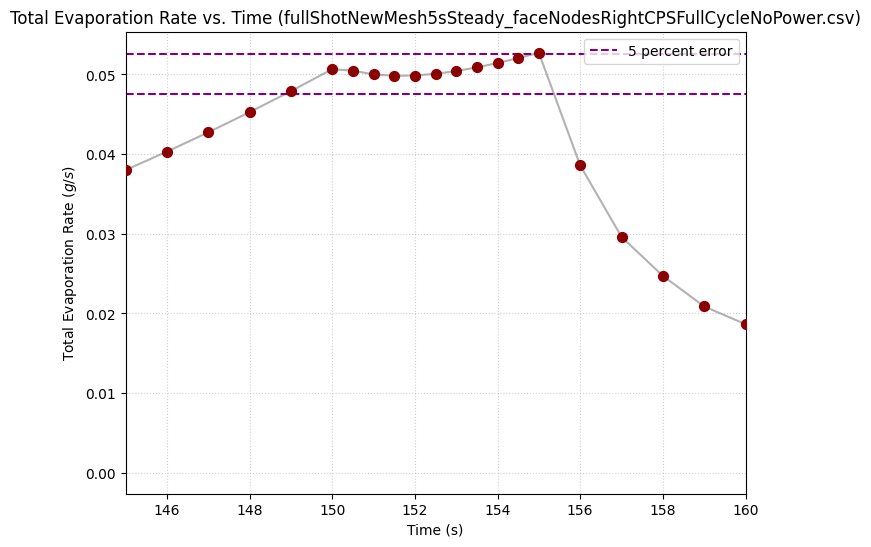

Summary plot saved as evap_vs_time_summary_fullShotNewMesh5sSteady_faceNodesRightCPSFullCycleNoPower.csv.png


In [67]:
plt.figure(figsize=(8, 6))

# plt.scatter(np.array(times)[sort_idx], np.array(summary_evap_rates)[sort_idx], color='darkred', s=100, label='Data Points', zorder=3)
# plt.scatter(sorted_times, sorted_evap, color='darkred', s=100, label='Data Points', zorder=3)

print(summary_temps)
plt.scatter(np.array(times)[sort_idx], np.array(summary_evap_rates)[sort_idx], color='darkred', s=50,  zorder=3)
plt.plot(np.array(times)[sort_idx], np.array(summary_evap_rates)[sort_idx], color='gray', alpha=0.6)
# plt.text(0, 0.05, amount_evaporated, fontsize=12)
plt.title(f"Total Evaporation Rate vs. Time ({name_tag}_{face_filename})")
plt.xlabel("Time (s)")
# plt.vlines(x= [40, 41], ymin=0, ymax=1, label="Pulse Duration", colors='purple', linestyles='dashed')
plt.hlines(y=[0.05-0.05*0.05, 0.05+0.05*0.05], xmin=145, xmax=160, label="5 percent error", colors='purple', linestyles='dashed')
plt.xlim(145, 160)
plt.legend()
# plt.yscale('log')
plt.ylabel("Total Evaporation Rate ($g/s$)")
plt.grid(True, linestyle=':', alpha=0.6)
summary_save_name = f'evap_vs_time_summary_{name_tag}_{face_filename}.png'

if saveFigures:
        plt.savefig(summary_save_name, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Summary plot saved as {summary_save_name}")



Summary plot saved as avgTemp_vs_time_fullShotNewMesh5sSteady.png


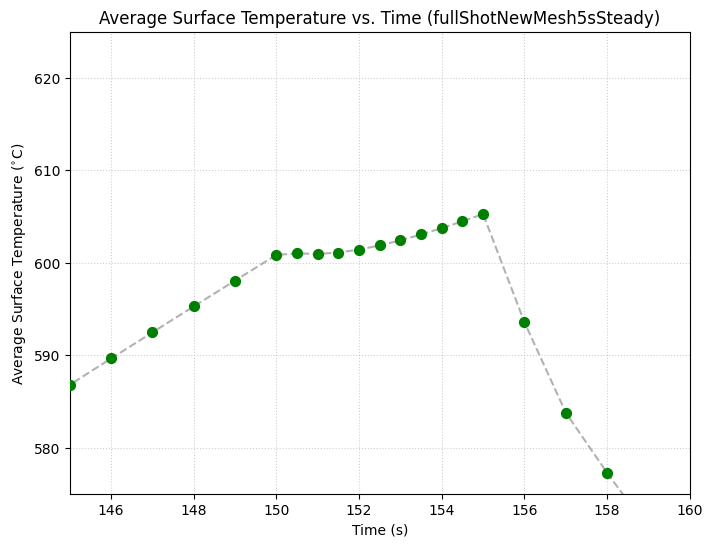

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(times, summary_temps, color='green', s=50, zorder=3)

plt.plot(np.array(times)[sort_idx], np.array(summary_temps)[sort_idx], 
        linestyle='--', color='gray', alpha=0.6)

plt.title(f"Average Surface Temperature vs. Time ({name_tag})")
plt.xlabel("Time (s)")
plt.ylabel(r"Average Surface Temperature ($^{\circ}$C)")
plt.xlim(145, 160)
plt.ylim(575, 625)
plt.grid(True, linestyle=':', alpha=0.6)
if saveFigures:
        summary_save_name = f'avgTemp_vs_time_{name_tag}.png'
        plt.savefig(summary_save_name, dpi=300, bbox_inches='tight')
        print(f"Summary plot saved as {summary_save_name}")
plt.show()



In [57]:
Temps150 = np.array([ 22.00752433,  24.15716807,  29.43639785,  36.97041751,
        45.60320569,  54.73901581,  64.01072827,  73.20290225,
        82.19400943,  90.91826621,  99.34372761, 107.45972469,
       115.26835533, 122.77863487, 130.00335609, 136.95791771,
       143.65795703, 150.11955302, 156.35786382, 162.38802932,
       168.22433146, 173.88090964, 179.37034485, 184.70448383,
       189.89462403, 194.95181678, 199.88512618, 204.70411404,
       209.41627578, 214.03024932, 218.552818  , 222.99065145,
       227.34982276, 231.63591149, 235.85436955, 240.00987483,
       244.10641226, 248.14898871, 252.14103509, 256.0859345 ,
       259.98767802, 263.84870889, 267.67186447, 271.45955151,
       275.2147037 , 278.93927342, 282.63512226, 286.30402435,
       289.94817324, 293.56875816, 297.1672449 , 300.74520222,
       304.30358005, 307.84402434, 311.3667342 , 314.87328814,
       318.36473598, 321.84122535, 325.30395127, 328.75367562,
       332.1910342 , 335.61629348, 339.03029235, 342.4337711 ,
       345.82646952, 349.20935571, 352.58278018, 355.94686236,
       359.3020018 , 362.64869317, 365.98691117, 369.31722656,
       372.63976354, 375.95420949, 379.26120719, 382.56108668,
       385.85325091, 389.13872826, 392.41649129, 395.68747146,
       398.95130514, 402.2080409 , 405.45817535, 408.70124016,
       411.93730783, 415.16625386, 418.38865296, 421.60371304,
       424.81134351, 428.01156599, 431.2048484 , 434.39080375,
       437.5691325 , 440.74007222, 443.90325733, 447.05865259,
       450.20603678, 453.34549806, 456.4767437 , 459.5995528 ,
       462.71412327, 465.81982763, 468.9169985 , 472.00541235,
       475.08439016, 478.15431644, 481.21531954, 484.26662733,
       487.30865684, 490.34148236, 493.3641538 , 496.37731671,
       499.38058846, 502.37371195, 505.35658658, 508.32897916,
       511.29073419, 514.24207443, 517.18216048, 520.1105996 ,
       523.02804663, 525.93336284, 528.82664411, 531.70790781,
       534.5764026 , 537.4324333 , 540.27568536, 543.10530231,
       545.92149835, 548.72409373, 551.51287449, 554.28712456,
       557.04723327, 559.79255008, 562.52257043, 565.23772207,
       567.9378871 , 570.62190772, 573.29057077, 575.94276966,
       578.57932249, 581.19918439, 583.80249288, 586.38934435,
       588.95906514, 591.51143641, 594.04667327, 596.56472516,
       599.06516429, 601.5483638 ])
Times150 = np.array([1.000000e-01, 1.106000e+00, 2.112100e+00, 3.118100e+00,
       4.124200e+00, 5.130200e+00, 6.136200e+00, 7.142300e+00,
       8.148300e+00, 9.154400e+00, 1.016040e+01, 1.116640e+01,
       1.217250e+01, 1.317850e+01, 1.418460e+01, 1.519060e+01,
       1.619660e+01, 1.720270e+01, 1.820870e+01, 1.921480e+01,
       2.022080e+01, 2.122680e+01, 2.223290e+01, 2.323890e+01,
       2.424500e+01, 2.525100e+01, 2.625700e+01, 2.726310e+01,
       2.826910e+01, 2.927520e+01, 3.028120e+01, 3.128720e+01,
       3.229330e+01, 3.329930e+01, 3.430540e+01, 3.531140e+01,
       3.631740e+01, 3.732350e+01, 3.832950e+01, 3.933560e+01,
       4.034160e+01, 4.134770e+01, 4.235370e+01, 4.335970e+01,
       4.436580e+01, 4.537180e+01, 4.637790e+01, 4.738390e+01,
       4.838990e+01, 4.939600e+01, 5.040200e+01, 5.140810e+01,
       5.241410e+01, 5.342010e+01, 5.442620e+01, 5.543220e+01,
       5.643830e+01, 5.744430e+01, 5.845030e+01, 5.945640e+01,
       6.046240e+01, 6.146850e+01, 6.247450e+01, 6.348050e+01,
       6.448660e+01, 6.549260e+01, 6.649870e+01, 6.750470e+01,
       6.851070e+01, 6.951680e+01, 7.052280e+01, 7.152890e+01,
       7.253490e+01, 7.354090e+01, 7.454700e+01, 7.555300e+01,
       7.655910e+01, 7.756510e+01, 7.857110e+01, 7.957720e+01,
       8.058320e+01, 8.158930e+01, 8.259530e+01, 8.360130e+01,
       8.460740e+01, 8.561340e+01, 8.661950e+01, 8.762550e+01,
       8.863150e+01, 8.963760e+01, 9.064360e+01, 9.164970e+01,
       9.265570e+01, 9.366170e+01, 9.466780e+01, 9.567380e+01,
       9.667990e+01, 9.768590e+01, 9.869190e+01, 9.969800e+01,
       1.007040e+02, 1.017101e+02, 1.027161e+02, 1.037221e+02,
       1.047282e+02, 1.057342e+02, 1.067403e+02, 1.077463e+02,
       1.087523e+02, 1.097584e+02, 1.107644e+02, 1.117705e+02,
       1.127765e+02, 1.137826e+02, 1.147886e+02, 1.157946e+02,
       1.168007e+02, 1.178067e+02, 1.188128e+02, 1.198188e+02,
       1.208248e+02, 1.218309e+02, 1.228369e+02, 1.238430e+02,
       1.248490e+02, 1.258550e+02, 1.268611e+02, 1.278671e+02,
       1.288732e+02, 1.298792e+02, 1.308852e+02, 1.318913e+02,
       1.328973e+02, 1.339034e+02, 1.349094e+02, 1.359154e+02,
       1.369215e+02, 1.379275e+02, 1.389336e+02, 1.399396e+02,
       1.409456e+02, 1.419517e+02, 1.429577e+02, 1.439638e+02,
       1.449698e+02, 1.459758e+02, 1.469819e+02, 1.479879e+02,
       1.489940e+02, 1.500000e+02])

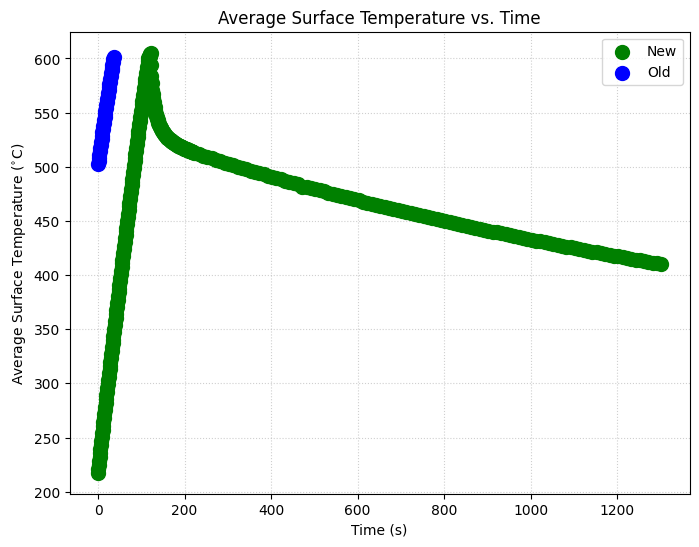

Summary plot saved as avgTemp_vs_time_fullShotNewMesh5sSteady.png


In [58]:
plt.figure(figsize=(8, 6))
plt.scatter(np.array(times)[sort_idx][33:]-33.6, np.array(summary_temps)[sort_idx][33:], color='green', s=100, zorder=3, label = "New")
plt.scatter(np.array(Times150)[113:]-113.8, np.array(Temps150)[113:], color='blue', s=100, zorder=3, label = "Old")

# sort_idx = np.argsort(summary_temps)

plt.title(f"Average Surface Temperature vs. Time")
plt.xlabel("Time (s)")
plt.ylabel(r"Average Surface Temperature ($^{\circ}$C)")
# plt.ylim(0, 650)
# plt.xlim(0, 150)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

summary_save_name = f'avgTemp_vs_time_{name_tag}.png'
# plt.savefig(summary_save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Summary plot saved as {summary_save_name}")

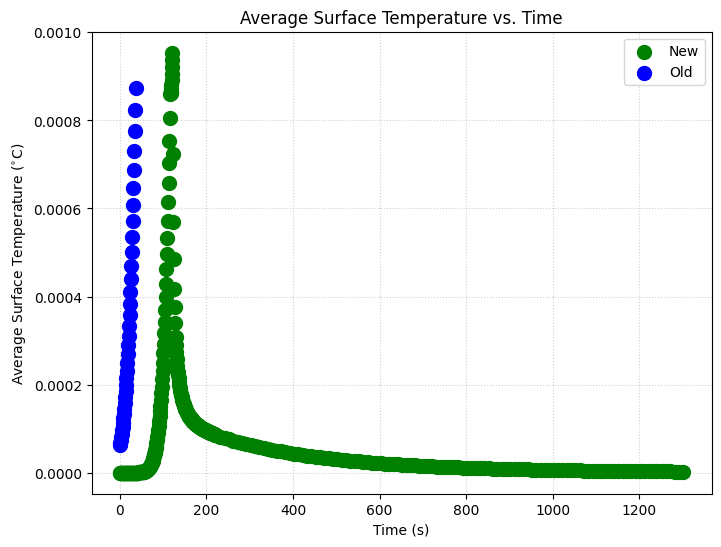

Summary plot saved as avgTemp_vs_time_fullShotNewMesh5sSteady.png


In [59]:
evaporation_rate_150 = G_max(Temps150 + 273.15)*6.94/6.022e23 # Convert to g/cm^2/s
total_evaporation_rate_150 = np.nansum(evaporation_rate_150) * dA_cm2
evaporation_rate_60 = G_max(np.array(summary_temps )+ 273.15)*6.94/6.022e23 # Convert to g/cm^2/s
total_evaporation_rate_60 = np.nansum(evaporation_rate_60) * dA_cm2
plt.figure(figsize=(8, 6))
plt.scatter(np.array(times)[sort_idx][33:]-33.6, np.array(evaporation_rate_60)[sort_idx][33:], color='green', s=100, zorder=3, label = "New")
plt.scatter(np.array(Times150)[113:]-113.8, np.array(evaporation_rate_150)[113:], color='blue', s=100, zorder=3, label = "Old")

# sort_idx = np.argsort(summary_temps)

plt.title(f"Average Surface Temperature vs. Time")
plt.xlabel("Time (s)")
plt.ylabel(r"Average Surface Temperature ($^{\circ}$C)")
# plt.ylim(0, 650)
# plt.xlim(0, 150)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

summary_save_name = f'avgTemp_vs_time_{name_tag}.png'
# plt.savefig(summary_save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Summary plot saved as {summary_save_name}")

In [60]:
np.array(Times150)[113]

np.float64(113.7826)

In [61]:
np.array(Temps150)[113]

np.float64(502.37371195)

[ 22.71785046,  55.01820784,  92.08273665, 126.00749293,
       156.68074045, 184.48310845, 209.80279503, 232.9637329 ,
       254.23178172, 273.82824685, 291.93965689, 308.72422115,
       324.31730503, 338.83551686, 352.37914789, 365.03637408,
       376.88429139, 387.99170497, 398.42073728, 408.2262182 ,
       417.45810083, 426.16214234, 434.38053354, 442.15207261,
       449.51325146, 456.49637263, 463.13327235, 469.45159259,
       475.47752086, 481.23517655, 486.74632065, 492.03137064,
       497.10826861, 501.99351819, 506.70190129, 511.24705693,
       515.64135828, 519.89545193, 524.01893518, 528.02163446,
       531.91045108, 535.69301127, 539.37581019, 542.96447341,
       546.46401157, 549.87946639, 553.21486379, 556.47407544,
       559.66131138, 562.77891486, 565.83011386, 568.81731643,
       571.74373732, 574.611066  , 577.42140859, 580.17699606,
       582.87914375, 585.5301844 , 588.1312365 , 590.68539229]

[ 0.1   ,  1.1153,  2.1305,  3.1458,  4.161 ,  5.1763,  6.1915,
        7.2068,  8.222 ,  9.2373, 10.2525, 11.2678, 12.2831, 13.2983,
       14.3136, 15.3288, 16.3441, 17.3593, 18.3746, 19.3898, 20.4051,
       21.4203, 22.4356, 23.4508, 24.4661, 25.4814, 26.4966, 27.5119,
       28.5271, 29.5424, 30.5576, 31.5729, 32.5881, 33.6034, 34.6186,
       35.6339, 36.6492, 37.6644, 38.6797, 39.6949, 40.7102, 41.7254,
       42.7407, 43.7559, 44.7712, 45.7864, 46.8017, 47.8169, 48.8322,
       49.8475, 50.8627, 51.878 , 52.8932, 53.9085, 54.9237, 55.939 ,
       56.9542, 57.9695, 58.9847, 60.    ]

[ 22.00752433,  24.15716807,  29.43639785,  36.97041751,
        45.60320569,  54.73901581,  64.01072827,  73.20290225,
        82.19400943,  90.91826621,  99.34372761, 107.45972469,
       115.26835533, 122.77863487, 130.00335609, 136.95791771,
       143.65795703, 150.11955302, 156.35786382, 162.38802932,
       168.22433146, 173.88090964, 179.37034485, 184.70448383,
       189.89462403, 194.95181678, 199.88512618, 204.70411404,
       209.41627578, 214.03024932, 218.552818  , 222.99065145,
       227.34982276, 231.63591149, 235.85436955, 240.00987483,
       244.10641226, 248.14898871, 252.14103509, 256.0859345 ,
       259.98767802, 263.84870889, 267.67186447, 271.45955151,
       275.2147037 , 278.93927342, 282.63512226, 286.30402435,
       289.94817324, 293.56875816, 297.1672449 , 300.74520222,
       304.30358005, 307.84402434, 311.3667342 , 314.87328814,
       318.36473598, 321.84122535, 325.30395127, 328.75367562,
       332.1910342 , 335.61629348, 339.03029235, 342.4337711 ,
       345.82646952, 349.20935571, 352.58278018, 355.94686236,
       359.3020018 , 362.64869317, 365.98691117, 369.31722656,
       372.63976354, 375.95420949, 379.26120719, 382.56108668,
       385.85325091, 389.13872826, 392.41649129, 395.68747146,
       398.95130514, 402.2080409 , 405.45817535, 408.70124016,
       411.93730783, 415.16625386, 418.38865296, 421.60371304,
       424.81134351, 428.01156599, 431.2048484 , 434.39080375,
       437.5691325 , 440.74007222, 443.90325733, 447.05865259,
       450.20603678, 453.34549806, 456.4767437 , 459.5995528 ,
       462.71412327, 465.81982763, 468.9169985 , 472.00541235,
       475.08439016, 478.15431644, 481.21531954, 484.26662733,
       487.30865684, 490.34148236, 493.3641538 , 496.37731671,
       499.38058846, 502.37371195, 505.35658658, 508.32897916,
       511.29073419, 514.24207443, 517.18216048, 520.1105996 ,
       523.02804663, 525.93336284, 528.82664411, 531.70790781,
       534.5764026 , 537.4324333 , 540.27568536, 543.10530231,
       545.92149835, 548.72409373, 551.51287449, 554.28712456,
       557.04723327, 559.79255008, 562.52257043, 565.23772207,
       567.9378871 , 570.62190772, 573.29057077, 575.94276966,
       578.57932249, 581.19918439, 583.80249288, 586.38934435,
       588.95906514, 591.51143641, 594.04667327, 596.56472516,
       599.06516429, 601.5483638 ]

[1.000000e-01, 1.106000e+00, 2.112100e+00, 3.118100e+00,
       4.124200e+00, 5.130200e+00, 6.136200e+00, 7.142300e+00,
       8.148300e+00, 9.154400e+00, 1.016040e+01, 1.116640e+01,
       1.217250e+01, 1.317850e+01, 1.418460e+01, 1.519060e+01,
       1.619660e+01, 1.720270e+01, 1.820870e+01, 1.921480e+01,
       2.022080e+01, 2.122680e+01, 2.223290e+01, 2.323890e+01,
       2.424500e+01, 2.525100e+01, 2.625700e+01, 2.726310e+01,
       2.826910e+01, 2.927520e+01, 3.028120e+01, 3.128720e+01,
       3.229330e+01, 3.329930e+01, 3.430540e+01, 3.531140e+01,
       3.631740e+01, 3.732350e+01, 3.832950e+01, 3.933560e+01,
       4.034160e+01, 4.134770e+01, 4.235370e+01, 4.335970e+01,
       4.436580e+01, 4.537180e+01, 4.637790e+01, 4.738390e+01,
       4.838990e+01, 4.939600e+01, 5.040200e+01, 5.140810e+01,
       5.241410e+01, 5.342010e+01, 5.442620e+01, 5.543220e+01,
       5.643830e+01, 5.744430e+01, 5.845030e+01, 5.945640e+01,
       6.046240e+01, 6.146850e+01, 6.247450e+01, 6.348050e+01,
       6.448660e+01, 6.549260e+01, 6.649870e+01, 6.750470e+01,
       6.851070e+01, 6.951680e+01, 7.052280e+01, 7.152890e+01,
       7.253490e+01, 7.354090e+01, 7.454700e+01, 7.555300e+01,
       7.655910e+01, 7.756510e+01, 7.857110e+01, 7.957720e+01,
       8.058320e+01, 8.158930e+01, 8.259530e+01, 8.360130e+01,
       8.460740e+01, 8.561340e+01, 8.661950e+01, 8.762550e+01,
       8.863150e+01, 8.963760e+01, 9.064360e+01, 9.164970e+01,
       9.265570e+01, 9.366170e+01, 9.466780e+01, 9.567380e+01,
       9.667990e+01, 9.768590e+01, 9.869190e+01, 9.969800e+01,
       1.007040e+02, 1.017101e+02, 1.027161e+02, 1.037221e+02,
       1.047282e+02, 1.057342e+02, 1.067403e+02, 1.077463e+02,
       1.087523e+02, 1.097584e+02, 1.107644e+02, 1.117705e+02,
       1.127765e+02, 1.137826e+02, 1.147886e+02, 1.157946e+02,
       1.168007e+02, 1.178067e+02, 1.188128e+02, 1.198188e+02,
       1.208248e+02, 1.218309e+02, 1.228369e+02, 1.238430e+02,
       1.248490e+02, 1.258550e+02, 1.268611e+02, 1.278671e+02,
       1.288732e+02, 1.298792e+02, 1.308852e+02, 1.318913e+02,
       1.328973e+02, 1.339034e+02, 1.349094e+02, 1.359154e+02,
       1.369215e+02, 1.379275e+02, 1.389336e+02, 1.399396e+02,
       1.409456e+02, 1.419517e+02, 1.429577e+02, 1.439638e+02,
       1.449698e+02, 1.459758e+02, 1.469819e+02, 1.479879e+02,
       1.489940e+02, 1.500000e+02]

In [62]:
np.array(times)[sort_idx]

array([1.000e-01, 1.000e+00, 2.000e+00, 3.000e+00, 4.000e+00, 5.000e+00,
       6.000e+00, 7.000e+00, 8.000e+00, 9.000e+00, 1.000e+01, 1.100e+01,
       1.200e+01, 1.300e+01, 1.400e+01, 1.500e+01, 1.600e+01, 1.700e+01,
       1.800e+01, 1.900e+01, 2.000e+01, 2.100e+01, 2.200e+01, 2.300e+01,
       2.400e+01, 2.500e+01, 2.600e+01, 2.700e+01, 2.800e+01, 2.900e+01,
       3.000e+01, 3.100e+01, 3.200e+01, 3.300e+01, 3.400e+01, 3.500e+01,
       3.600e+01, 3.700e+01, 3.800e+01, 3.900e+01, 4.000e+01, 4.100e+01,
       4.200e+01, 4.300e+01, 4.400e+01, 4.500e+01, 4.600e+01, 4.700e+01,
       4.800e+01, 4.900e+01, 5.000e+01, 5.100e+01, 5.200e+01, 5.300e+01,
       5.400e+01, 5.500e+01, 5.600e+01, 5.700e+01, 5.800e+01, 5.900e+01,
       6.000e+01, 6.100e+01, 6.200e+01, 6.300e+01, 6.400e+01, 6.500e+01,
       6.600e+01, 6.700e+01, 6.800e+01, 6.900e+01, 7.000e+01, 7.100e+01,
       7.200e+01, 7.300e+01, 7.400e+01, 7.500e+01, 7.600e+01, 7.700e+01,
       7.800e+01, 7.900e+01, 8.000e+01, 8.100e+01, 

In [63]:
np.linspace(0.1, 150, 150)

array([1.00000000e-01, 1.10604027e+00, 2.11208054e+00, 3.11812081e+00,
       4.12416107e+00, 5.13020134e+00, 6.13624161e+00, 7.14228188e+00,
       8.14832215e+00, 9.15436242e+00, 1.01604027e+01, 1.11664430e+01,
       1.21724832e+01, 1.31785235e+01, 1.41845638e+01, 1.51906040e+01,
       1.61966443e+01, 1.72026846e+01, 1.82087248e+01, 1.92147651e+01,
       2.02208054e+01, 2.12268456e+01, 2.22328859e+01, 2.32389262e+01,
       2.42449664e+01, 2.52510067e+01, 2.62570470e+01, 2.72630872e+01,
       2.82691275e+01, 2.92751678e+01, 3.02812081e+01, 3.12872483e+01,
       3.22932886e+01, 3.32993289e+01, 3.43053691e+01, 3.53114094e+01,
       3.63174497e+01, 3.73234899e+01, 3.83295302e+01, 3.93355705e+01,
       4.03416107e+01, 4.13476510e+01, 4.23536913e+01, 4.33597315e+01,
       4.43657718e+01, 4.53718121e+01, 4.63778523e+01, 4.73838926e+01,
       4.83899329e+01, 4.93959732e+01, 5.04020134e+01, 5.14080537e+01,
       5.24140940e+01, 5.34201342e+01, 5.44261745e+01, 5.54322148e+01,
      

In [64]:
[1,2]+[3,4]

[1, 2, 3, 4]